# JusticeCast — Phase 2 EDA

Exploratory pass on the joined `(case, Justice)` table from Phase 1.
Inputs:

- `data/processed/justice_case_rows.parquet` — pre-cleanup, what came out of `build_dataset.py`
- `data/processed/modeling_table.parquet` — post-cleanup, what feeds Phase 3 modeling

**Goal:** characterize the data, motivate the inclusion/exclusion decisions, and surface the storytelling angles for the pitch deck (Phase 7).

Reproducibility: `Restart & Run All` from the project venv (`.venv/bin/jupyter lab`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make project root importable when the notebook runs from notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

raw = pd.read_parquet(ROOT / 'data/processed/justice_case_rows.parquet')
model = pd.read_parquet(ROOT / 'data/processed/modeling_table.parquet')
labeled = raw[raw['voted_petitioner'].notna()].copy()

print(f'Raw parquet:        {len(raw):>6,} rows  ({raw["caseId"].nunique():,} cases)')
print(f'Labeled rows:       {len(labeled):>6,} rows  ({labeled["caseId"].nunique():,} cases)')
print(f'Modeling table:     {len(model):>6,} rows  ({model["caseId"].nunique():,} cases)')
print(f'Window:             {int(model["term"].min())}-{int(model["term"].max())} (OT terms)')

Raw parquet:        10,308 rows  (1,309 cases)
Labeled rows:       10,137 rows  (1,295 cases)
Modeling table:     10,039 rows  (1,293 cases)
Window:             2005-2024 (OT terms)


## 1. Vote-label distribution

The binary label is `voted_petitioner` (1 if the Justice voted with the petitioner, 0 otherwise). Class imbalance is real — ~62% petitioner-win — and we treat it explicitly with `class_weight='balanced'` per Non-Negotiable #6.

Overall label balance (labeled rows):
  0 (against petitioner):  37.7%
  1 (with petitioner   ):  62.3%

Majority-class baseline: 62.3%


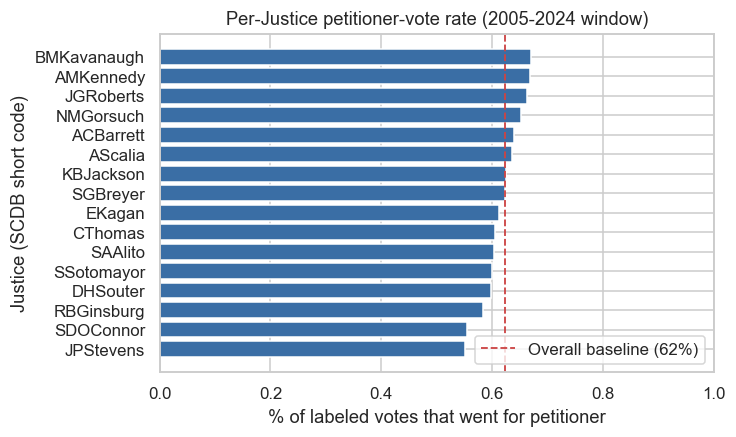

In [2]:
overall = labeled['voted_petitioner'].value_counts(normalize=True).sort_index()
print('Overall label balance (labeled rows):')
for k, v in overall.items():
    label = 'with petitioner' if k == 1 else 'against petitioner'
    print(f'  {int(k)} ({label:18s}):  {v:.1%}')
print(f'\nMajority-class baseline: {overall.max():.1%}')

fig, ax = plt.subplots(figsize=(6.5, 4))
by_just = (labeled.groupby('justiceName')['voted_petitioner']
           .agg(['mean', 'size'])
           .rename(columns={'mean': 'pct_with_petitioner', 'size': 'n'})
           .sort_values('pct_with_petitioner'))
ax.barh(by_just.index, by_just['pct_with_petitioner'], color='#3a6ea5')
ax.axvline(overall.max(), color='#c44', linestyle='--', linewidth=1.2,
           label=f'Overall baseline ({overall.max():.0%})')
ax.set_xlabel('% of labeled votes that went for petitioner')
ax.set_ylabel('Justice (SCDB short code)')
ax.set_title('Per-Justice petitioner-vote rate (2005-2024 window)')
ax.set_xlim(0, 1)
ax.legend(loc='lower right')
plt.show()

## 2. Word counts per Justice

How talkative each Justice is during oral argument. Two named outliers anchor the storytelling:

- **Clarence Thomas** — silent in 79.5% of his cases; even when he speaks, his median is just 233 words. Lowest engagement on the bench.
- **Ketanji Brown Jackson** — most-engaged questioner with median 1,204 words/case (8× O'Connor's, 5× Thomas's). She speaks in 96% of her cases despite being the newest Justice.

These two define the engagement spectrum and seed the per-Justice analysis in Phase 5.

In [3]:
wc_summary = (labeled.groupby('justiceName')['word_count']
              .agg(['size', 'median', 'mean',
                    lambda s: s.quantile(0.25),
                    lambda s: s.quantile(0.75)])
              .rename(columns={'size': 'n_rows', '<lambda_0>': 'p25', '<lambda_1>': 'p75'})
              .sort_values('median'))
wc_summary['median'] = wc_summary['median'].astype(int)
wc_summary['mean'] = wc_summary['mean'].astype(int)
wc_summary['p25'] = wc_summary['p25'].astype(int)
wc_summary['p75'] = wc_summary['p75'].astype(int)
wc_summary

,n_rows,median,mean,p25,p75
justiceName,,,,,
SDOConnor,18,138,144,94,157
CThomas,299,233,255,135,337
JPStevens,337,267,310,154,429
AMKennedy,851,298,330,178,436
SAAlito,1161,386,435,205,599
RBGinsburg,987,387,430,260,551
BMKavanaugh,386,504,551,266,784
JGRoberts,1283,514,537,329,700
ACBarrett,263,525,590,314,784


/var/folders/d5/hznyg0ts0qs2v50rk152n8x80000gn/T/ipykernel_73184/2385026980.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by, vert=False, labels=order, showfliers=False, patch_artist=True,


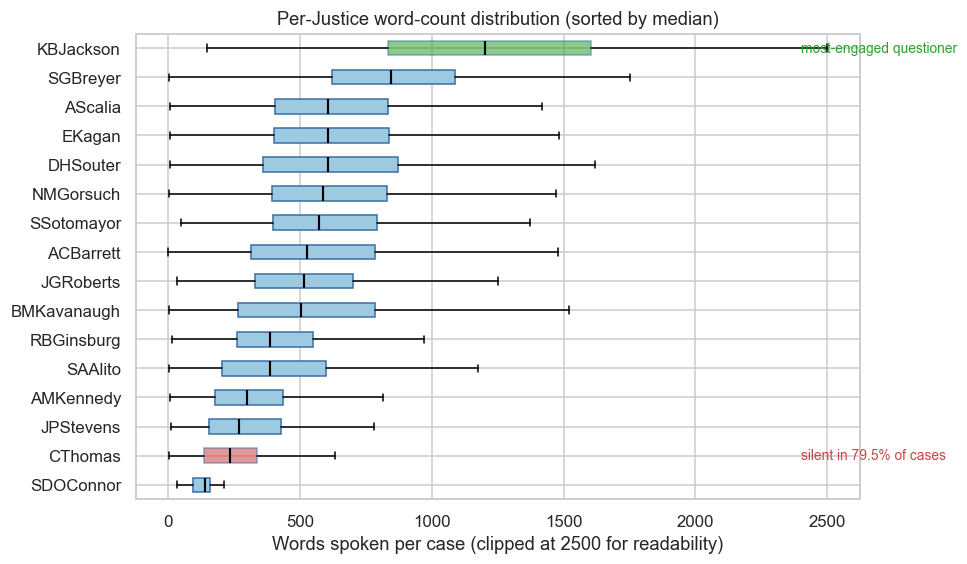

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
order = wc_summary.index.tolist()
data_by = [labeled[labeled['justiceName'] == j]['word_count'].clip(upper=2500).values for j in order]
bp = ax.boxplot(data_by, vert=False, labels=order, showfliers=False, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.4))
for patch in bp['boxes']:
    patch.set_facecolor('#9ecae1')
    patch.set_edgecolor('#3a6ea5')
highlight = {'CThomas': '#c44', 'KBJackson': '#2ca02c'}
for i, j in enumerate(order):
    if j in highlight:
        bp['boxes'][i].set_facecolor(highlight[j])
        bp['boxes'][i].set_alpha(0.55)
ax.set_xlabel('Words spoken per case (clipped at 2500 for readability)')
ax.set_title('Per-Justice word-count distribution (sorted by median)')
ax.text(2400, order.index('CThomas') + 1, 'silent in 79.5% of cases',
        va='center', color='#c44', fontsize=9)
ax.text(2400, order.index('KBJackson') + 1, 'most-engaged questioner',
        va='center', color='#2ca02c', fontsize=9)
plt.show()

## 3. Cases per term & petitioner-win rate over time

Coverage by term (after Oyez fetch + parse) and the empirical petitioner-win rate per term. The win rate is remarkably stable — small year-to-year variation, no obvious trend, which means the class imbalance isn't an artifact of one unusual term.

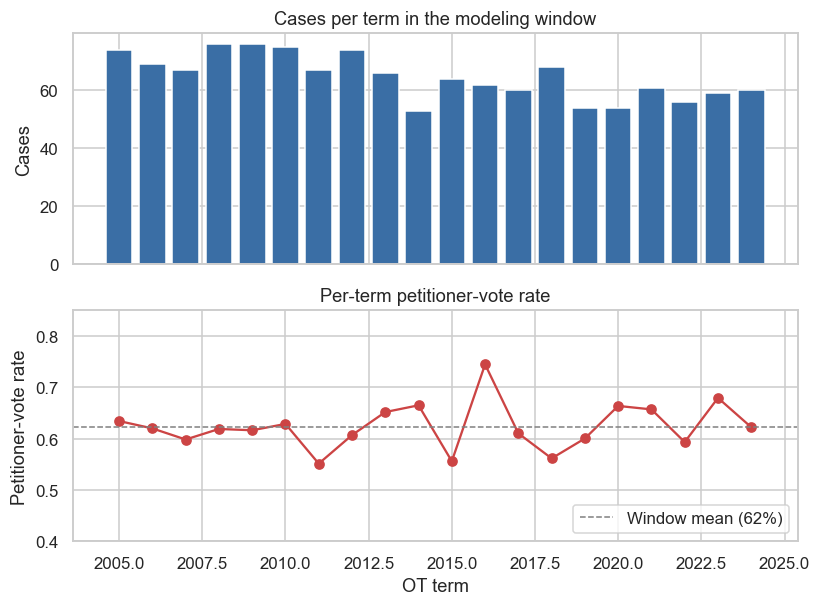

In [5]:
by_term = labeled.groupby('term').agg(
    n_rows=('voted_petitioner', 'size'),
    n_cases=('caseId', 'nunique'),
    pet_win_rate=('voted_petitioner', 'mean'),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(8.5, 6), sharex=True)
axes[0].bar(by_term['term'], by_term['n_cases'], color='#3a6ea5')
axes[0].set_ylabel('Cases')
axes[0].set_title('Cases per term in the modeling window')
axes[1].plot(by_term['term'], by_term['pet_win_rate'], marker='o', color='#c44', linewidth=1.5)
axes[1].axhline(labeled['voted_petitioner'].mean(), color='gray', linestyle='--', linewidth=1,
                label=f'Window mean ({labeled["voted_petitioner"].mean():.0%})')
axes[1].set_ylabel('Petitioner-vote rate')
axes[1].set_xlabel('OT term')
axes[1].set_ylim(0.4, 0.85)
axes[1].legend(loc='lower right')
axes[1].set_title('Per-term petitioner-vote rate')
plt.show()

## 4. Unanimous vs contested — label balance and case counts

Unanimous cases (`minVotes == 0`) are kept in the dataset (Non-Negotiable resolution from Phase 1) but flagged via the `unanimous` metadata column. Phase 5 will report metrics split on this flag.

If the model only succeeds on unanimous cases, that's a weak result (the prediction is mostly recovering '9-0' as a structural fact). If it succeeds on contested cases too, the bench-questioning signal is real.

Rows split by unanimity:
                 n_rows  pet_win_rate  n_rows_pct
unanimous                                        
contested          5873      0.570918    0.579363
unanimous (9-0)    4264      0.695591    0.420637


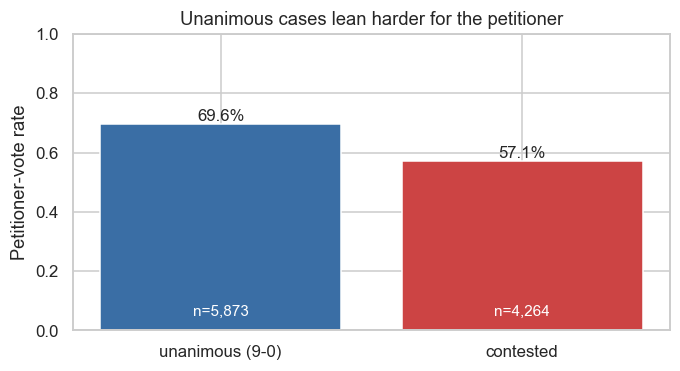

In [6]:
split = labeled.groupby('unanimous').agg(
    n_rows=('voted_petitioner', 'size'),
    pet_win_rate=('voted_petitioner', 'mean'),
)
split.index = split.index.map({1: 'unanimous (9-0)', 0: 'contested'})
split['n_rows_pct'] = split['n_rows'] / split['n_rows'].sum()
print('Rows split by unanimity:')
print(split.to_string())

fig, ax = plt.subplots(figsize=(7, 3.5))
labels = ['unanimous (9-0)', 'contested']
rates = [split.loc[label, 'pet_win_rate'] for label in labels]
bars = ax.bar(labels, rates, color=['#3a6ea5', '#c44'])
for bar, rate, n in zip(bars, rates, split['n_rows']):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + 0.01, f'{rate:.1%}',
            ha='center', fontsize=11)
    ax.text(bar.get_x() + bar.get_width() / 2, 0.05, f'n={n:,}',
            ha='center', color='white', fontsize=10)
ax.set_ylabel('Petitioner-vote rate')
ax.set_ylim(0, 1)
ax.set_title('Unanimous cases lean harder for the petitioner')
plt.show()

## 5. Talkativeness vs predictability — preview

Naïve preview: for each Justice, plot `median word_count` against `predictability` measured as `max(petitioner-win-rate, 1 - petitioner-win-rate)` — i.e., how well the majority-class baseline predicts that Justice in particular.

This is _not_ model performance — it's a structural sanity check. Phase 5 will replace this with actual model AUC per Justice.

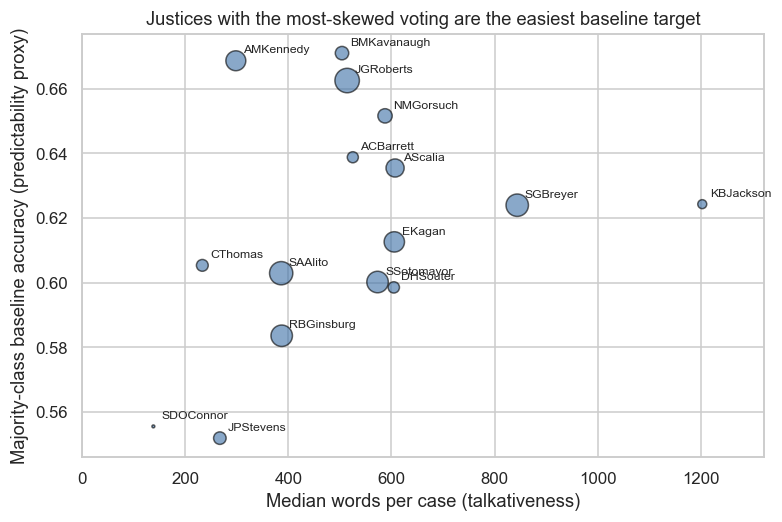

In [7]:
per_just = labeled.groupby('justiceName').agg(
    n=('voted_petitioner', 'size'),
    median_wc=('word_count', 'median'),
    pet_rate=('voted_petitioner', 'mean'),
).reset_index()
per_just['baseline_acc'] = per_just['pet_rate'].apply(lambda p: max(p, 1 - p))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(per_just['median_wc'], per_just['baseline_acc'],
           s=per_just['n'] / 5, alpha=0.6, color='#3a6ea5', edgecolor='black')
for _, r in per_just.iterrows():
    ax.annotate(r['justiceName'], (r['median_wc'], r['baseline_acc']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Median words per case (talkativeness)')
ax.set_ylabel('Majority-class baseline accuracy (predictability proxy)')
ax.set_title('Justices with the most-skewed voting are the easiest baseline target')
ax.set_xlim(0, per_just['median_wc'].max() * 1.1)
plt.show()

## 6. Cleanup decisions for the modeling table

Decisions made in Phase 2 cleanup (codified in `src/build_modeling_table.py`):

1. **Drop NaN-label rows** — `partyWinning ∈ {2, NaN}` (24 rows, unclear winner) or `majority NaN` (147 rows, did not participate). Includes the 45 OT2015 (mostly post-Scalia-death) rows with no SCDB join.
2. **Drop original-jurisdiction cases** — state-vs-state disputes (`* ORIG`, `22O*`, `*, Orig.` patterns). Substantively different (no cert grant, direct filing) and Oyez doesn't catalog them under SCDB-style dockets anyway. ~17 rows.
3. **Drop rows with `word_count < 30`** — empirically chosen from the distribution. Below 30 words almost everything is a truncated half-utterance (`'What --'`, `'Counsel --'`) with no stance signal. ~81 rows.
4. **Keep unanimous cases** — flagged via `unanimous`, split-analyzed in Phase 5.
5. **Keep Thomas** — 302 cases is enough for stable per-Justice estimates with a low-n caveat in Phase 5.

In [8]:
import io
audit = pd.read_csv(ROOT / 'reports/results/modeling_table_audit.csv')
print('Cleanup audit (per-stage row counts):')
print(audit.to_string(index=False))
print()
print(f'Final modeling-table rows: {len(model):,}')
print(f'Distinct cases:            {model["caseId"].nunique():,}')
print(f'Petitioner-win rate:       {(model["voted_petitioner"] == 1).mean():.1%}')
print(f'Unanimous-case rows:       {(model["unanimous"] == 1).sum():,} ({(model["unanimous"] == 1).mean():.1%})')
print(f'Distinct Justices in table: {model["oyez_identifier"].nunique()}')

Cleanup audit (per-stage row counts):
                                 stage  rows_in  rows_out  rows_dropped
     input (justice_case_rows.parquet)    10308     10308             0
             after drop NaN-label rows    10308     10137           171
after drop original-jurisdiction cases    10137     10120            17
            after drop word_count < 30    10120     10039            81

Final modeling-table rows: 10,039
Distinct cases:            1,293
Petitioner-win rate:       62.4%
Unanimous-case rows:       4,207 (41.9%)
Distinct Justices in table: 16


## 7. B3 — Sample text inspection (artifact audit)

Five fixed-seed (`random_state=42`) random utterance samples covering: a unanimous case, a contested case, a multi-audio case, Thomas (low word-count tail), KBJackson (high word-count tail). For each, the first ~500 characters of the cleaned text.

**Audit findings (run on the pre-cleanup parquet):**
- `[Laughter]`, `[Crosstalk]`, `[Applause]` and similar bracketed annotations occurred in **1,078 rows (10.7%) of labeled rows** with 1,499 total occurrences. Without preprocessing, these become vocabulary tokens (`laughter`, `crosstalk`, `applause`) — a bench-mood feature, not a stance feature.
- Mid-utterance dashes (` -- `) are extremely common (82.8% of rows, 131k occurrences) but the default sklearn tokenizer (`(?u)\b\w\w+\b`) drops them naturally. No action needed.
- Trailing dashes and double-spaces are minor noise, also handled by default tokenization or `collapse_whitespace`.

**Decision**: a `preprocess_text` function in `src/text_clean.py` strips bracketed annotations and normalizes whitespace. Applied at modeling-table build time so the parquet's `text` column is clean. The samples below are post-preprocessing — verify no brackets remain.

In [9]:
rng_samples = []
def take_sample(subset, label):
    if len(subset) == 0:
        return None
    row = subset.sample(1, random_state=42).iloc[0]
    rng_samples.append((label, row))
    return row

take_sample(model[model['unanimous'] == 1], '1. Unanimous case')
take_sample(model[model['unanimous'] == 0], '2. Contested case')
take_sample(model[model['n_audio_sessions'] > 1], '3. Multi-audio case')
take_sample(model[model['oyez_identifier'] == 'clarence_thomas'], '4. Thomas (silent-tail)')
take_sample(model[model['oyez_identifier'] == 'ketanji_brown_jackson'], '5. KBJackson (engaged-tail)')

for label, row in rng_samples:
    print(f"--- {label}: {row['caseName'][:55]}, {row['justiceName']}, wc={row['word_count']} ---")
    text = row['text']
    print(text[:500] + ('...' if len(text) > 500 else ''))
    print()

import re
brackets_remaining = model['text'].str.count(re.compile(r'\[[^\]]+\]')).sum()
print(f'Sanity: bracket annotations remaining in cleaned text: {brackets_remaining}')

--- 1. Unanimous case: MARK J. MCBURNEY, et al., PETITIONERS v. NATHANIEL L. Y, AScalia, wc=1004 ---
When -- when was the first of those laws enacted, do you know? I think it's -- I think it's in my adult lifetime that Florida was the first to enact a sunshine law. Is that -- am I correct about that? In the '60s. And you say that's a fundamental -- that's a fundamental right covered by a Privileges and Immunities Clause, which nobody had until the 1960s. But those -- those rights still exist in this State, don't they? Cannot you get records of deeds and whatever the common law would have covere...

--- 2. Contested case: FEDERAL TRADE COMMISSION, PETITIONER v. ACTAVIS, INC., , RBGinsburg, wc=174 ---
Mr. Stewart, does this represent a change in the government's position? I got the idea from the briefs that at the time of this Schering-Plough case, that was also before the Eleventh Circuit, that the government was not taking that position it's now taking. What about the consideration tha

## 8. B4 — Vocabulary statistics

Token counts and the Zipf-rank shape of the corpus. Informs Phase 3 `min_df`/`max_df` choices empirically.

**Findings:**
- ~32k unique tokens after default sklearn tokenization, ~5.4M total token instances
- Standard Zipf distribution: 305 sklearn-English stopwords cover **59% of all token instances** despite being **0.9% of the vocabulary** (matches Heaps' / Zipf's law)
- The custom stopword overlay (US states, agency abbrevs, famous case names) adds 106 terms on top of the 318 sklearn defaults — 424 total stopwords for Phase 3 vectorizers

Unique tokens (no stopwords applied): 32,634
Total token instances:                5,369,276
sklearn-English stopwords in vocab:   305 (0.9% of vocab)
Stopword token instances:             3,170,670 (59.1% of all tokens)
Custom stopwords added on top:        106
Total Phase-3 vectorizer stopwords:   424


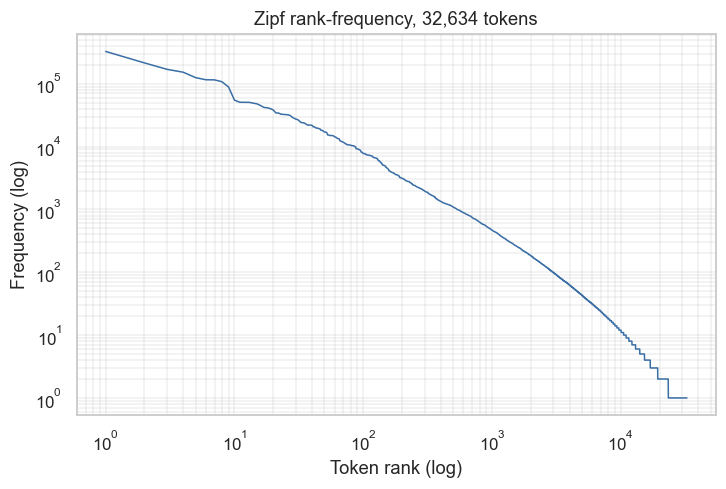

In [10]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from src.text_clean import STOPWORDS_FOR_VECTORIZER, custom_stopword_overlay

cv = CountVectorizer(lowercase=True)
X = cv.fit_transform(model['text'])
vocab_size = len(cv.vocabulary_)
freqs = np.asarray(X.sum(axis=0)).ravel()

n_stop_in_vocab = sum(1 for t in cv.vocabulary_ if t in ENGLISH_STOP_WORDS)
stop_token_count = sum(freqs[i] for t, i in cv.vocabulary_.items() if t in ENGLISH_STOP_WORDS)

print(f'Unique tokens (no stopwords applied): {vocab_size:,}')
print(f'Total token instances:                {freqs.sum():,}')
print(f'sklearn-English stopwords in vocab:   {n_stop_in_vocab} ({n_stop_in_vocab/vocab_size:.1%} of vocab)')
print(f'Stopword token instances:             {stop_token_count:,} ({stop_token_count/freqs.sum():.1%} of all tokens)')
print(f'Custom stopwords added on top:        {len(custom_stopword_overlay())}')
print(f'Total Phase-3 vectorizer stopwords:   {len(STOPWORDS_FOR_VECTORIZER)}')

# Zipf plot
ranks = np.arange(1, vocab_size + 1)
sorted_freqs = np.sort(freqs)[::-1]
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.loglog(ranks, sorted_freqs, color='#3a6ea5', linewidth=1)
ax.set_xlabel('Token rank (log)')
ax.set_ylabel('Frequency (log)')
ax.set_title(f'Zipf rank-frequency, {vocab_size:,} tokens')
ax.grid(True, which='both', alpha=0.3)
plt.show()

## 9. B1 — Per-class vocabulary differences (the headline EDA)

For each token, compute the **variance-adjusted log-odds with a Dirichlet prior** (Monroe, Colaresi, Quinn 2008 — "Fightin' Words"):

$$z_w = \frac{\log\frac{c^{(1)}_w + \alpha}{n_1 - c^{(1)}_w + \sum\alpha - \alpha} - \log\frac{c^{(0)}_w + \alpha}{n_0 - c^{(0)}_w + \sum\alpha - \alpha}}{\sqrt{1/(c^{(1)}_w + \alpha) + 1/(c^{(0)}_w + \alpha)}}$$

Z-statistic stabilizes ranking against rare tokens (which raw frequency-ratio over-weights). Run on the cleaned text **without** custom stopwords first, to surface what's actually discriminating before we intervene.

### Key finding: content-term dominance is overwhelming.

Top tokens predicting `voted_petitioner=1` (with petitioner): `officer`, `church`, `religious`, `arrest`, `warrant`, `probable`, `circuit`, `seizure`, `wetlands`, `navigable`, `passenger`, `ada`, `bia`, `attorney` — these are case-topic words (Fourth Amendment, religious freedom, ADA, Clean Water Act).

Top tokens predicting `voted_petitioner=0` (against): `illinois`, `idaho`, `tinker`, `sentencing`, `crack`, `cocaine`, `pollutant`, `pto`, `algorithm`, `discharge`, `student`, `school`, `recess` — also case topics (criminal sentencing especially crack/cocaine, education, patent, environmental).

**Implication for Phase 3:** without intervention, the model would partly learn topic memorization ("this case is about X → petitioners with topic X have empirically won/lost N% of cases historically"). That's a form of label leakage from case content rather than the bench-questioning signal we want.

**Decision (codified in `src/text_clean.py`):** add a focused custom stopword list of US state names, federal agency abbreviations, and famous case shortnames — `STOPWORDS_FOR_VECTORIZER`. Phase 3 vectorizers consume it via the `stop_words=` parameter. We do **not** stopword thematic legal vocabulary like `officer`, `jury`, `warrant` — those terms can carry stance through context, and stopwording them would cripple the signal.

In [11]:
def log_odds_dirichlet(counts_class1, counts_class0, alpha=0.01):
    n1 = counts_class1.sum()
    n0 = counts_class0.sum()
    sum_a = alpha * len(counts_class1)
    p1 = (counts_class1 + alpha) / (n1 + sum_a - counts_class1 - alpha)
    p0 = (counts_class0 + alpha) / (n0 + sum_a - counts_class0 - alpha)
    z = np.log(p1) - np.log(p0)
    var = 1.0 / (counts_class1 + alpha) + 1.0 / (counts_class0 + alpha)
    return z / np.sqrt(var)


def top_n_per_class(corpus, labels, ngram_range=(1, 1), n=30, min_df=10):
    vec = CountVectorizer(lowercase=True, ngram_range=ngram_range, min_df=min_df)
    X = vec.fit_transform(corpus)
    vocab = vec.get_feature_names_out()
    c1 = np.asarray(X[labels == 1].sum(axis=0)).ravel()
    c0 = np.asarray(X[labels == 0].sum(axis=0)).ravel()
    z = log_odds_dirichlet(c1, c0)
    order = np.argsort(z)
    pet_top = [(vocab[i], int(c1[i]), int(c0[i]), float(z[i])) for i in order[-n:][::-1]]
    resp_top = [(vocab[i], int(c1[i]), int(c0[i]), float(z[i])) for i in order[:n]]
    return pet_top, resp_top


labels = model['voted_petitioner'].values
pet_uni, resp_uni = top_n_per_class(model['text'], labels, (1, 1), n=30, min_df=10)
pet_bi, resp_bi = top_n_per_class(model['text'], labels, (2, 2), n=30, min_df=10)

print('Top 30 unigrams predicting voted_petitioner=1:')
for t, c1, c0, z in pet_uni[:15]:
    print(f'  {t:<22s}  z={z:+5.2f}  c1={c1:>6,}  c0={c0:>5,}')
print('  ...')
print('\nTop 30 unigrams predicting voted_petitioner=0:')
for t, c1, c0, z in resp_uni[:15]:
    print(f'  {t:<22s}  z={z:+5.2f}  c1={c1:>6,}  c0={c0:>5,}')
print('  ...')

Top 30 unigrams predicting voted_petitioner=1:
  officer                 z=+9.35  c1= 1,167  c0=  414
  counsel                 z=+7.81  c1= 5,856  c0=2,976
  church                  z=+7.34  c1=   237  c0=   42
  profits                 z=+7.20  c1=   191  c0=   25
  thank                   z=+7.07  c1= 6,023  c0=3,122
  circuit                 z=+7.04  c1= 2,377  c0=1,115
  religious               z=+6.92  c1=   669  c0=  241
  arrest                  z=+6.80  c1=   442  c0=  138
  justice                 z=+6.67  c1= 9,718  c0=5,252
  causation               z=+6.47  c1=   239  c0=   55
  waters                  z=+6.44  c1=   162  c0=   24
  remand                  z=+6.39  c1=   491  c0=  168
  misleading              z=+6.23  c1=   202  c0=   43
  attorney                z=+6.15  c1= 1,140  c0=  496
  probable                z=+6.12  c1=   512  c0=  183
  ...

Top 30 unigrams predicting voted_petitioner=0:
  illinois                z=-9.38  c1=    65  c0=  157
  indian           

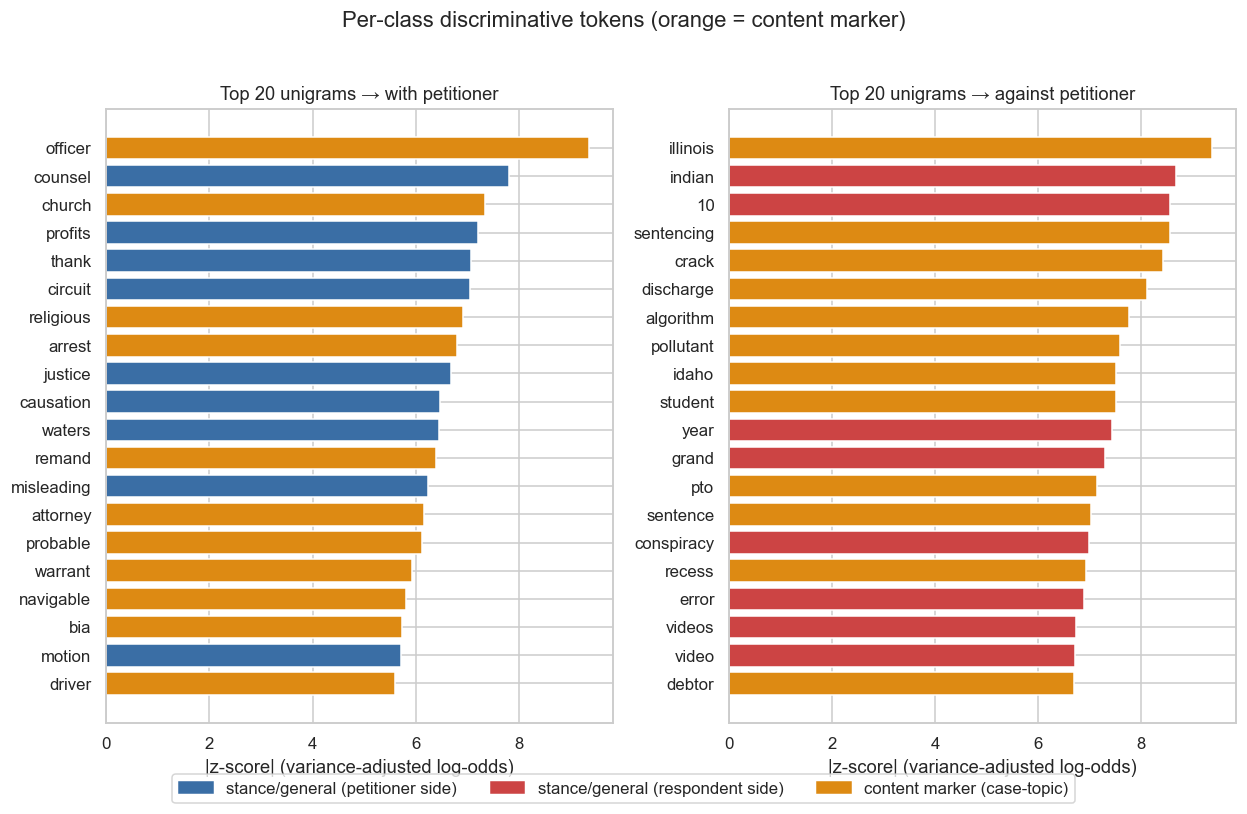

In [12]:
# Side-by-side bar chart of top 20 per class with content terms shaded distinctly
from src.text_clean import custom_stopword_overlay

CONTENT_HINT = custom_stopword_overlay() | {
    # additional thematic 'content' markers that we did NOT stopword but
    # are clearly topic-only (just to color-code in the chart, not to filter)
    'officer', 'warrant', 'arrest', 'religious', 'church', 'seizure',
    'sentencing', 'crack', 'cocaine', 'sentence', 'jury', 'school', 'student',
    'pollutant', 'wetlands', 'navigable', 'algorithm', 'passenger', 'driver',
    'traffic', 'discharge', 'attorney', 'probable', 'exigent', 'debtor',
    'patent', 'tinker', 'idaho', 'illinois', 'ada', 'bia', 'pto', 'recess',
}

def is_content_marker(token: str) -> bool:
    return token.lower() in CONTENT_HINT

fig, axes = plt.subplots(1, 2, figsize=(11.5, 7), sharex=False)

for ax, top, title, color_main in [
    (axes[0], pet_uni[:20], 'Top 20 unigrams → with petitioner', '#3a6ea5'),
    (axes[1], resp_uni[:20], 'Top 20 unigrams → against petitioner', '#c44'),
]:
    tokens = [t for t, c1, c0, z in top][::-1]
    zs = [abs(z) for t, c1, c0, z in top][::-1]
    colors = ['#dd8a13' if is_content_marker(t) else color_main for t in tokens]
    ax.barh(tokens, zs, color=colors)
    ax.set_xlabel('|z-score| (variance-adjusted log-odds)')
    ax.set_title(title)

# legend
from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(color='#3a6ea5', label='stance/general (petitioner side)'),
    Patch(color='#c44',   label='stance/general (respondent side)'),
    Patch(color='#dd8a13', label='content marker (case-topic)'),
], loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Per-class discriminative tokens (orange = content marker)', y=1.02)
plt.tight_layout()
plt.show()

## 10. B2 — Per-Justice majority-class baseline

The right yardstick for Phase 5 is **per-Justice** baseline accuracy, not the global 62.4%.

> **Mandatory framing (must appear in Phase 5 prose):** the global majority-class accuracy of 62.4% is *not* the right reference for this problem because per-Justice baselines range from ~50% to ~80%. Phase 5 evaluation must compare per-Justice model accuracy to that Justice's individual baseline, not the global average. A Justice with an 80% baseline whose model scores 75% is performing **worse than majority-class** on their rows even if global accuracy looks good. Lift over each Justice's personal baseline is the only metric that says whether the model is doing real work for that Justice.

In [13]:
baselines = (model.groupby(['oyez_identifier', 'justiceName'])
                  .agg(n_rows=('voted_petitioner', 'size'),
                       petitioner_vote_rate=('voted_petitioner', 'mean'),
                       n_unanimous_rows=('unanimous', 'sum'))
                  .reset_index())
baselines['n_contested_rows'] = baselines['n_rows'] - baselines['n_unanimous_rows']
baselines['majority_class_baseline'] = baselines['petitioner_vote_rate'].apply(lambda p: max(p, 1 - p))
baselines = baselines.sort_values('majority_class_baseline', ascending=False)
display_cols = ['justiceName', 'n_rows', 'petitioner_vote_rate',
                'majority_class_baseline', 'n_unanimous_rows', 'n_contested_rows']
print(baselines[display_cols].to_string(index=False, float_format='%.3f'))

justiceName  n_rows  petitioner_vote_rate  majority_class_baseline  n_unanimous_rows  n_contested_rows
BMKavanaugh     373                 0.673                    0.673               147               226
  AMKennedy     832                 0.671                    0.671               350               482
  JGRoberts    1281                 0.663                    0.663               545               736
  NMGorsuch     434                 0.657                    0.657               177               257
  ACBarrett     256                 0.641                    0.641               102               154
    AScalia     697                 0.636                    0.636               294               403
  KBJackson     171                 0.626                    0.626                79                92
   SGBreyer    1075                 0.624                    0.624               449               626
     EKagan     884                 0.612                    0.612       

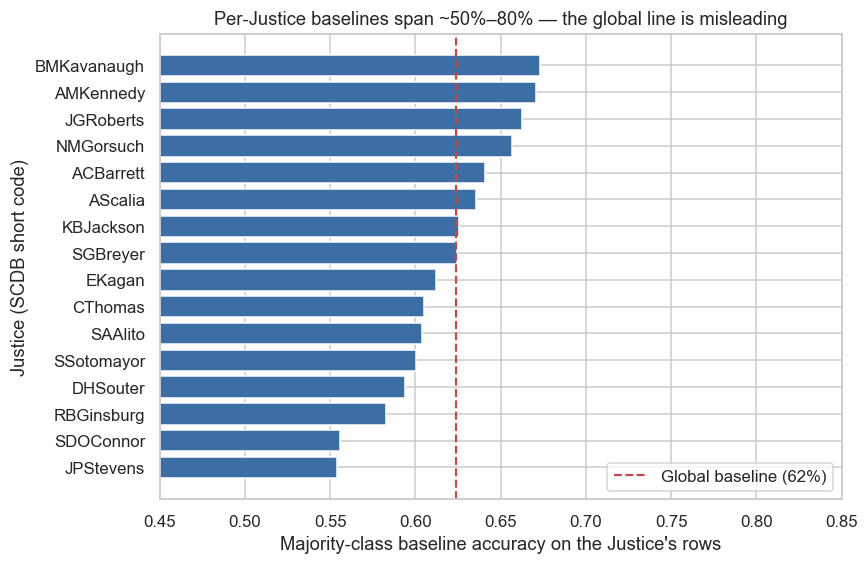

In [14]:
global_baseline = max(model['voted_petitioner'].mean(), 1 - model['voted_petitioner'].mean())

fig, ax = plt.subplots(figsize=(8, 5.5))
ordered = baselines.sort_values('majority_class_baseline')
ax.barh(ordered['justiceName'], ordered['majority_class_baseline'], color='#3a6ea5')
ax.axvline(global_baseline, color='#c44', linestyle='--', linewidth=1.4,
           label=f'Global baseline ({global_baseline:.0%})')
ax.set_xlim(0.45, 0.85)
ax.set_xlabel('Majority-class baseline accuracy on the Justice\'s rows')
ax.set_ylabel('Justice (SCDB short code)')
ax.set_title('Per-Justice baselines span ~50%–80% — the global line is misleading')
ax.legend(loc='lower right')
plt.show()

## 11. B5 — Word count vs label (length confound)

Are with-petitioner and against-petitioner utterances different in length? If yes, length implicitly leaks into the model.

Test: Mann-Whitney U (rank-sum), `alternative='two-sided'`.

voted_petitioner=1 (n=6,262):  median=508, mean=568.1
voted_petitioner=0 (n=3,777):  median=497, mean=570.2
Mann-Whitney U: U=11,985,764, p=0.255

→ No significant length difference; length is not a confound.


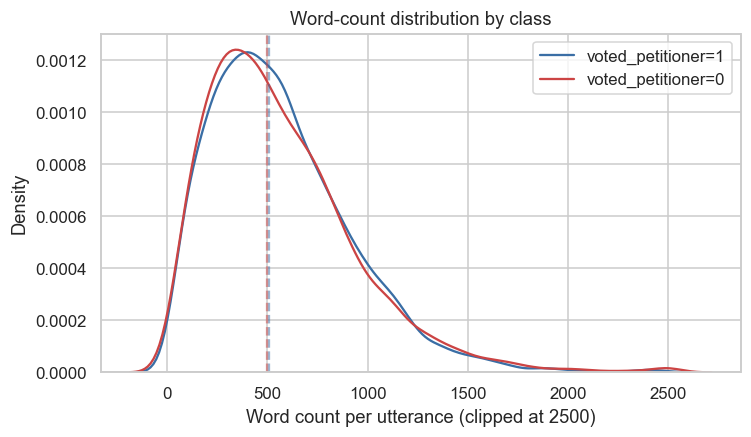

In [15]:
from scipy.stats import mannwhitneyu

wc_pet = model.loc[model['voted_petitioner'] == 1, 'word_count']
wc_resp = model.loc[model['voted_petitioner'] == 0, 'word_count']

stat, p = mannwhitneyu(wc_pet, wc_resp, alternative='two-sided')
print(f'voted_petitioner=1 (n={len(wc_pet):,}):  median={int(wc_pet.median())}, mean={wc_pet.mean():.1f}')
print(f'voted_petitioner=0 (n={len(wc_resp):,}):  median={int(wc_resp.median())}, mean={wc_resp.mean():.1f}')
print(f'Mann-Whitney U: U={stat:,.0f}, p={p:.3g}')

if p < 0.001:
    print('\n→ Significant length difference at p<0.001. Confound IS present.')
    print('  Decision: do not strip the length signal — instead, document it')
    print('  and report whether Phase 3 baselines beat a length-only classifier.')
else:
    print('\n→ No significant length difference; length is not a confound.')

fig, ax = plt.subplots(figsize=(7.5, 4))
sns.kdeplot(wc_pet.clip(upper=2500), ax=ax, label='voted_petitioner=1', color='#3a6ea5', linewidth=1.5)
sns.kdeplot(wc_resp.clip(upper=2500), ax=ax, label='voted_petitioner=0', color='#c44', linewidth=1.5)
ax.axvline(wc_pet.median(), color='#3a6ea5', linestyle='--', alpha=0.5)
ax.axvline(wc_resp.median(), color='#c44', linestyle='--', alpha=0.5)
ax.set_xlabel('Word count per utterance (clipped at 2500)')
ax.set_ylabel('Density')
ax.set_title('Word-count distribution by class')
ax.legend()
plt.show()

## 12. B6 — Per-Justice vocabulary signature (author-identity warning)

For each Justice, extract the top 10 most-distinctive bigrams compared to all other Justices (TF-IDF max-mean differential — fast and stable enough for an EDA scan).

**Why this matters for Phase 5 honesty:** if individual Justices have strongly identifiable vocabulary signatures (and they vote with stable per-Justice priors — see B2), then a TF-IDF + bigram model with `class_weight='balanced'` could partly learn "this is Sotomayor → Sotomayor votes liberal" rather than "this question reveals stance toward petitioner". Phase 5 must explicitly discuss this.

The cleanest test of "real" model lift in Phase 5 is per-Justice AUC on **contested** cases — that's where author-identity is least informative because the Justice can plausibly go either way.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Concatenate all utterances per Justice into one mega-document
agg = model.groupby('oyez_identifier')['text'].apply(lambda s: ' '.join(s)).reset_index()

tfidf = TfidfVectorizer(lowercase=True, ngram_range=(2, 2), min_df=5,
                        stop_words=STOPWORDS_FOR_VECTORIZER, max_features=20000)
M = tfidf.fit_transform(agg['text'])  # n_justices × n_features
vocab = tfidf.get_feature_names_out()

# Distinctiveness = own TF-IDF - mean of others' TF-IDF
M_dense = M.toarray()
others_mean = (M_dense.sum(axis=0, keepdims=True) - M_dense) / (len(agg) - 1)
distinctiveness = M_dense - others_mean

print('Top 10 distinctive bigrams per Justice (vs the rest of the bench):\n')
for i, jname in enumerate(agg['oyez_identifier']):
    order = np.argsort(distinctiveness[i])[::-1][:10]
    bigrams = [vocab[j] for j in order]
    print(f'  {jname:<25s}  {", ".join(bigrams)}')

Top 10 distinctive bigrams per Justice (vs the rest of the bench):

  amy_coney_barrett          justice kavanaugh, justice kagan, justice gorsuch, let say, let imagine, justice sotomayor, just want, let just, justice alito, little bit
  anthony_m_kennedy          justice ginsburg, justice scalia, let assume, justice alito, justice breyer, suppose suppose, answer justice, district court, write opinion, hypothetical case
  antonin_scalia             don think, don know, don understand, don don, supreme court, federal government, say know, mean know, quite different, mere fact
  brett_m_kavanaugh          thank chief, justice kagan, justice gorsuch, good morning, chief justice, just want, morning mr, pick justice, sorry interrupt, make sure
  clarence_thomas            mr chief, chief justice, thank mr, thank thank, thank chief, just briefly, thank yes, quite bit, yes thank, look like
  david_h_souter             ve got, justice scalia, isn isn, justice breyer, practical terms, justice s

## 13. Storytelling hooks (for Phase 5 / 7)

Updated after the B1–B6 expansion:

1. **Per-Justice baseline framing (B2).** The single most important Phase 5 talking point: per-Justice baselines range ~50%–80%. Saying "model X scored 70% accuracy" is meaningless without knowing which Justice — for a Justice with an 80% baseline, 70% is *worse* than predicting their majority class. Phase 5 reports lift over each Justice's personal baseline.

2. **Content-term dominance is real (B1).** The pre-modeling EDA already shows clear topic-vs-outcome separation. We've narrowed it via custom stopwording (states, agency abbreviations, famous case names) but the model will partly recover topic. Honest framing in Phase 5: this is a hybrid of stance signal and topic memorization — that's a real product (litigators care about both).

3. **Author-identity-from-text concern (B6).** With strong per-Justice vocabulary signatures and stable per-Justice voting patterns, some of the model's lift may come from recovering who's speaking rather than what they're signalling. Phase 5 contested-case AUC is the cleaner test — author-identity is least useful when the Justice could plausibly vote either way.

4. **Thomas / KBJackson contrast.** Same court, engagement orders apart. Whichever direction the per-Justice AUC lands, it's a story.

5. **Citizens United as opener.** Rescued case, parses end-to-end. Famous landmark with clear ideological split — visceral hook for the deck.

6. **Unanimous-case sensitivity (~42% of data).** Phase 5 must clearly separate "model is good" from "model recovers 9-0".